In [2]:
# ==============================
# RSS 新闻抓取：BBC Business 版本
# ==============================

# 导入 feedparser，用来解析 RSS 新闻
import feedparser

# BBC Business RSS 地址
# 这个地址用于获取 BBC 商业新闻
url = "http://feeds.bbci.co.uk/news/business/rss.xml"

# 解析 RSS
feed = feedparser.parse(url)

# 判断是否成功获取新闻
if len(feed.entries) == 0:
    print("没有抓取到新闻，请检查网络或 RSS 地址。")
else:
    print("成功抓取新闻！")
    print("=" * 50)

    # 输出前 10 条新闻
    for entry in feed.entries[:10]:
        print("标题：", entry.title)

        # 有些 RSS 用 published，有些用 updated
        if hasattr(entry, "published"):
            print("时间：", entry.published)
        elif hasattr(entry, "updated"):
            print("时间：", entry.updated)
        else:
            print("时间：暂无时间")

        print("-" * 50)

成功抓取新闻！
标题： World's largest chipmaker does not rule out price rises as costs increase
时间： Tue, 09 Jun 2026 22:00:24 GMT
--------------------------------------------------
标题： How to enjoy the World Cup - and keep your boss on side
时间： Tue, 09 Jun 2026 23:03:08 GMT
--------------------------------------------------
标题： Bill debt soars but many don't know help is available
时间： Tue, 09 Jun 2026 23:03:32 GMT
--------------------------------------------------
标题： Beauty Pie LED mask ad banned over misleading anti-wrinkle claim
时间： Tue, 09 Jun 2026 23:03:20 GMT
--------------------------------------------------
标题： Version of AI tool 'too powerful for public' released to public
时间： Tue, 09 Jun 2026 18:35:59 GMT
--------------------------------------------------
标题： Kalshi to make some users reveal job details to tackle insider trading
时间： Tue, 09 Jun 2026 22:32:31 GMT
--------------------------------------------------
标题： AI giants' race to raise funds heats up as ChatGPT-owner plans stock m

数据预览：
        date  USO_Close  GLD_Close  SPY_Close  QQQ_Close
0 2018-01-02      12.10     125.20     268.00     157.00
1 2018-01-03      12.10     125.74     268.73     157.08
2 2018-01-04      12.14     125.37     268.22     156.12
3 2018-01-05      12.23     124.53     267.95     157.14
4 2018-01-08      12.23     124.36     266.66     157.01

数据列名：
Index(['date', 'USO_Close', 'GLD_Close', 'SPY_Close', 'QQQ_Close'], dtype='object')


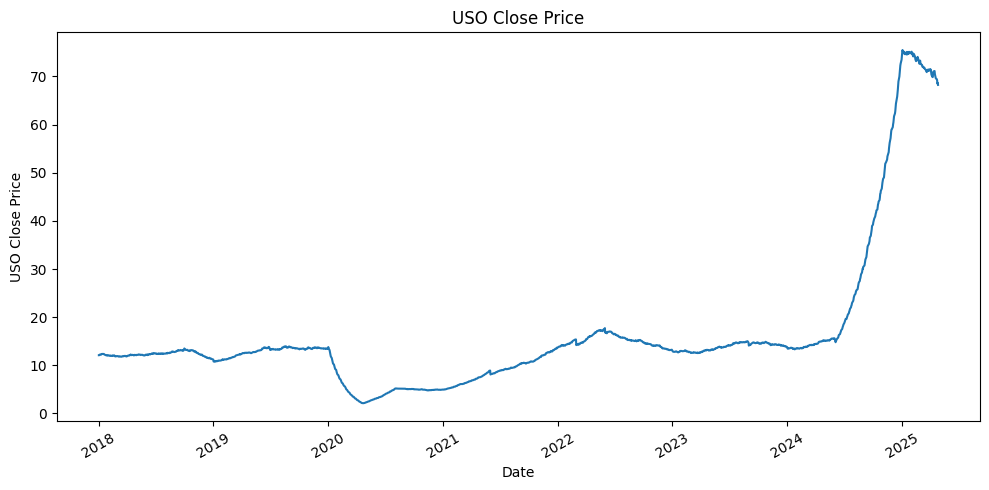

In [16]:
# ==============================
# TACO 第一节：本地 CSV 市场数据读取
# 不依赖 yfinance / Stooq / 外网
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. 设置 CSV 文件路径
file_path = Path("market_data_2018_2025.csv")

# 2. 判断文件是否存在
if not file_path.exists():
    print("没有找到 market_data_2018_2025.csv 文件。")
    print("请确认它和当前 Python 文件放在同一个文件夹里。")
else:
    # 3. 读取 CSV 文件
    # parse_dates=["date"]：把 date 列识别成日期
    df = pd.read_csv(file_path, parse_dates=["date"])

    # 4. 查看数据前 5 行
    print("数据预览：")
    print(df.head())

    # 5. 查看列名
    print("\n数据列名：")
    print(df.columns)

    # 6. 画 USO 收盘价折线图
    plt.figure(figsize=(10, 5))

    # 横轴：日期
    # 纵轴：USO 收盘价
    plt.plot(df["date"], df["USO_Close"])

    plt.title("USO Close Price")
    plt.xlabel("Date")
    plt.ylabel("USO Close Price")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [22]:
# ==============================
# yfinance 获取 USO 数据：课堂稳定版
# ==============================

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import time

symbol = "USO"

try:
    print(f"正在从 Yahoo Finance 获取 {symbol} 数据...")

    df = yf.download(
        symbol,
        period="6mo",
        interval="1d",
        progress=False,
        threads=False
    )

    time.sleep(3)

    if df.empty:
        print("没有获取到数据。")
        print("可能原因：网络问题、Yahoo Finance 限流、数据源暂时不可用。")
    else:
        print("成功获取数据！")
        print(df.head())

        print("\n数据列名：")
        print(df.columns)

        # 兼容普通列名和多层列名
        if isinstance(df.columns, pd.MultiIndex):
            close_price = df["Close"][symbol]
        else:
            close_price = df["Close"]

        plt.figure(figsize=(10, 5))
        plt.plot(close_price.index, close_price.values)

        plt.title("USO Close Price - Last 6 Months")
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print("yfinance 获取数据失败。")
    print("错误原因：", e)
    print("这通常不是代码语法错误，而是网络、访问限制或数据源问题。")

正在从 Yahoo Finance 获取 USO 数据...



1 Failed download:
['USO']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


没有获取到数据。
可能原因：网络问题、Yahoo Finance 限流、数据源暂时不可用。


读取 Stooq 网页失败。
错误原因： HTTP Error 404: Not Found
